# 07 ST-GCN recipe tuning, round 2: closing the top 1 gap

The first recipe round (notebook 04) found weight decay 5e-3 and a 300 clip per class sampler floor beat
the original baseline. On the held out test set that recipe reached 72.29% top 1 against Li et al.'s
74.41%, level on top 5 and MCA. This round looks for the remaining top 1 gap.

**Protocol.** Same discipline as round 1: validation only, tuning seeds (11, 22) separate from the
reporting seeds (42, 123, 7), test set not evaluated anywhere in this notebook. Starting point is the
round 1 recipe (`configs/stgcn_recipe.json`), not the original baseline.

**New factors.**

| factor | change | why |
|---|---|---|
| weight decay grid | 3e-3, 7e-3, 1e-2 | round 1 only checked one point above the old 1e-3; the peak was never located |
| longer patience | patience 30 instead of 20 | best epoch was 23 to 26 last time, close to the old stopping window |
| mixup | alpha 0.2, training batches only | blends two clips' pose sequences and labels (Zhang et al., 2018, adapted from images); a training time regulariser, not test time augmentation, so it does not conflict with the no ensembling / no TTA principle |

**Selection rule, fixed before running.** A factor helps if mean validation top 1 is at least 0.5 points
above the round 1 recipe and MCA does not drop by more than 1 point. Helping factors are combined in stage
B. Final choice is the highest validation top 1 among the round 1 recipe, the helping single factors and
the combination, ties within 0.3 points going to fewer changes.

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from clearml import Task

REPO = os.environ.get("BADMINTON_REPO", "/workspace/badminton-honours-project")
DATA = os.environ.get("BADMINTON_DATA", "/workspace/data")
sys.path.insert(0, REPO)
import dataset as ds
from models import stgcn as stgcn_model
import training as tr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

2.1.0+cu118 cuda NVIDIA GeForce RTX 4090


In [2]:
PROJECT = "BadmintonPoseAnalysis/experiments/stgcn_recipe_v2"
KEYPOINTS = f"{DATA}/keypoints_interp"
OUT = os.environ.get("BADMINTON_OUTPUTS", "/workspace/outputs") + "/experiments/stgcn_recipe_v2"
os.makedirs(OUT, exist_ok=True)

SEEDS = [11, 22]
SPLITS = ("train", "val")
NORMALISATION, USE_COURT = "body", True
NUM_WORKERS = 20

with open(f"{REPO}/configs/stgcn_recipe.json") as f:
    ROUND1 = json.load(f)

FIXED = {"model": "ST-GCN", "augmentation": "advanced", "min_native_frames": 5, "batch_size": 16, "lr": 0.01,
         "momentum": 0.9, "gamma": 0.1, "num_epochs": 70, "select_metric": "top1", "normalisation": "body_court"}
BASELINE = {"weight_decay": ROUND1["weight_decay"], "label_smoothing": ROUND1["label_smoothing"],
            "schedule": ROUND1["schedule"], "target_per_class": ROUND1["target_per_class"],
            "patience": 20, "mixup_alpha": 0.0}
FACTORS = {
    "wd_3e-3": {"weight_decay": 3e-3},
    "wd_7e-3": {"weight_decay": 7e-3},
    "wd_1e-2": {"weight_decay": 1e-2},
    "patience_30": {"patience": 30},
    "mixup_0.2": {"mixup_alpha": 0.2},
}
MIN_GAIN, MAX_MCA_DROP, TIE = 0.005, 0.01, 0.003
print("round 1 recipe:", BASELINE)

round 1 recipe: {'weight_decay': 0.005, 'label_smoothing': 0.0, 'schedule': 'step10', 'target_per_class': 300, 'patience': 20, 'mixup_alpha': 0.0}


In [3]:
manifest = ds.load_filtered_manifest(f"{DATA}/split_manifest.csv", f"{DATA}/extraction_log.csv",
                                     f"{DATA}/keypoints_interp_log.csv", FIXED["min_native_frames"])
class_names = sorted(manifest["class_name"].unique())
class_to_id = {c: i for i, c in enumerate(class_names)}
split_hash = open(f"{DATA}/split_manifest.sha256").read().split()[0]
forward = stgcn_model.make_forward(USE_COURT)
in_channels = 7 if USE_COURT else 5

manual review: dropped 4 clips
short clip rule: dropped 4 train clips with fewer than 5 real frames
7810 clips remain (train 6247, test 782, val 781)


## Run function

In [4]:
results_path = f"{OUT}/results.csv"


def load_results():
    return pd.read_csv(results_path) if os.path.exists(results_path) else pd.DataFrame(columns=["config", "seed"])


def run_config(name, overrides, seed):
    done = load_results()
    if ((done["config"] == name) & (done["seed"] == seed)).any():
        print(f"skip {name} seed {seed}, already done")
        return
    cfg = {**BASELINE, **overrides}
    run_name = f"stgcn_{name}_s{seed}"
    print(f"\n=== {run_name}  {overrides or 'round1 recipe'} ===")
    tr.seed_everything(seed)

    task = Task.init(project_name=PROJECT, task_name=run_name, task_type=Task.TaskTypes.training,
                     tags=["recipe_v2", name, "stgcn", f"seed{seed}"], reuse_last_task_id=False,
                     auto_connect_frameworks={"matplotlib": False, "pytorch": False})
    task.connect({**FIXED, **cfg, "config": name, "changes": overrides, "seed": seed,
                  "keypoints": KEYPOINTS, "split_sha256": split_hash, "evaluated_splits": list(SPLITS),
                  "round1_recipe": BASELINE})

    loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, FIXED["augmentation"], NORMALISATION, seed=seed,
                               batch_size=FIXED["batch_size"], target_per_class=cfg["target_per_class"],
                               num_workers=NUM_WORKERS, eval_workers=8)
    model = stgcn_model.build_stgcn(in_channels, len(class_names)).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=FIXED["lr"], momentum=FIXED["momentum"],
                                weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=FIXED["gamma"])
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg["label_smoothing"])

    _, history, best_epoch = tr.train_model(model, forward, loaders, optimizer, scheduler, criterion, device,
                                            task.get_logger(), num_epochs=FIXED["num_epochs"],
                                            patience=cfg["patience"], select_metric=FIXED["select_metric"],
                                            splits=SPLITS, mixup_alpha=cfg["mixup_alpha"], num_classes=len(class_names))
    metrics = tr.report_run(task, model, forward, loaders, class_names, device, history, best_epoch,
                            out_dir=f"{OUT}/{run_name}", run_name=run_name, splits=SPLITS, show=False,
                            extra={"config": name, "seed": seed})
    task.close()

    pd.concat([done, pd.DataFrame([metrics])], ignore_index=True).to_csv(results_path, index=False)
    del model, loaders
    torch.cuda.empty_cache()

## Smoke test

Run alone first: one mixup batch (checks soft label shape and that the loss is finite), one ordinary batch,
gradient check, and the two new patience/weight decay values sanity printed.

In [5]:
tr.seed_everything(0)
loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, FIXED["augmentation"], NORMALISATION, seed=0,
                           batch_size=FIXED["batch_size"], target_per_class=300, num_workers=2, eval_workers=2)
model = stgcn_model.build_stgcn(in_channels, len(class_names)).to(device)
batch = next(iter(loaders["train"]))

mixed = ds.mixup_batch(batch, alpha=0.2, num_classes=len(class_names))
assert mixed["soft_label"].shape == (FIXED["batch_size"], len(class_names))
assert torch.allclose(mixed["soft_label"].sum(1), torch.ones(FIXED["batch_size"]), atol=1e-5)
logits = forward(model, mixed, device)
loss = -(mixed["soft_label"].to(device) * torch.log_softmax(logits, dim=1)).sum(1).mean()
assert torch.isfinite(loss)
loss.backward()
assert not [n for n, p in model.named_parameters() if p.requires_grad and p.grad is None]
print(f"mixup smoke ok, loss {loss.item():.3f}, lambda check passed")

model.zero_grad()
logits = forward(model, batch, device)
nn.CrossEntropyLoss()(logits, batch["label"].to(device)).backward()
print("ordinary batch ok")
print(f"round 1 recipe weight_decay {BASELINE['weight_decay']}, grid to test: "
      f"{[FACTORS[k]['weight_decay'] for k in FACTORS if 'weight_decay' in FACTORS[k]]}")
del model, loaders
print("smoke test passed")

mixup smoke ok, loss 3.123, lambda check passed
ordinary batch ok
round 1 recipe weight_decay 0.005, grid to test: [0.003, 0.007, 0.01]
smoke test passed


## Stage A

Six configurations (round 1 recipe plus five factors) on two seeds: twelve runs.

In [6]:
configs_a = {"round1": {}, **FACTORS}
for name, overrides in configs_a.items():
    for seed in SEEDS:
        run_config(name, overrides, seed)

skip round1 seed 11, already done

=== stgcn_round1_s22  round1 recipe ===
ClearML Task: created new task id=335ead10590641a7bcc7515f939be453
2026-09-30 04:13:42,187 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/53a89d75f2f84713929afc6d6f97437e/tasks/335ead10590641a7bcc7515f939be453/output/log
epoch   0  loss 2.016  train 0.577  val 0.571 (mca 0.409)  *
epoch   1  loss 1.513  train 0.623  val 0.615 (mca 0.519)  *
epoch   3  loss 1.274  train 0.680  val 0.661 (mca 0.544)  *
epoch   5  loss 1.187  train 0.636  val 0.608 (mca 0.537)
epoch   6  loss 1.152  train 0.678  val 0.671 (mca 0.580)  *
epoch   7  loss 1.147  train 0.690  val 0.673 (mca 0.576)  *
epoch   8  loss 1.154  train 0.699  val 0.675 (mca 0.570)  *
epoch  10  loss 0.886  train 0.788  val 0.726 (mca 0.644)  *
epoch  11  loss 0.793  train 0.804  val 0.731 (mca 0.640)  *
epoch  15  loss 0.635  train 0.845  val 0.726 (mca 0.638)
epoch  19

███████████████████████████████ 100% | 11.66/11.66 MB [00:08<00:00,  1.40MB/s]: 



=== stgcn_wd_3e-3_s11  {'weight_decay': 0.003} ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=6de2cffa5c244f67b6bd33fcc01dcc52
ClearML results page: https://app.clear.ml/projects/53a89d75f2f84713929afc6d6f97437e/tasks/6de2cffa5c244f67b6bd33fcc01dcc52/output/log
epoch   0  loss 1.942  train 0.575  val 0.598 (mca 0.466)  *
epoch   1  loss 1.473  train 0.620  val 0.613 (mca 0.543)  *
epoch   2  loss 1.317  train 0.684  val 0.677 (mca 0.569)  *
epoch   5  loss 1.114  train 0.721  val 0.673 (mca 0.568)
epoch   6  loss 1.049  train 0.731  val 0.682 (mca 0.591)  *
epoch   7  loss 1.025  train 0.735  val 0.691 (mca 0.586)  *
epoch  10  loss 0.745  train 0.815  val 0.732 (mca 0.639)  *
epoch  12  loss 0.602  train 0.847  val 0.748 (mca 0.657)  *
epoch  15  loss 0.505  train 0.871  val 0.729 (mca 0.626)
epoch  20  loss 0.313  train 0.950  val 0.745 (mca 0.659)
epoch  25  loss 0.247  train 0.975  val 0.734 (mca 0.644)
epoch  26  loss 0.232  train 0.975  val 0.754 (mca 0.677)  *
epoch  30  loss 0.199  train 0.983  val 0.741 (mca 0.657)
epoch  35  loss 0.19

...

███████████████████████████████ 100% | 11.66/11.66 MB [00:06<00:00,  1.76MB/s]: 



=== stgcn_mixup_0.2_s22  {'mixup_alpha': 0.2} ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=70c735afcf6d4aa88202eaa38e5d2349
ClearML results page: https://app.clear.ml/projects/53a89d75f2f84713929afc6d6f97437e/tasks/70c735afcf6d4aa88202eaa38e5d2349/output/log
epoch   0  loss 2.167  train 0.595  val 0.598 (mca 0.421)  *
epoch   1  loss 1.790  train 0.628  val 0.604 (mca 0.510)  *
epoch   2  loss 1.647  train 0.640  val 0.635 (mca 0.563)  *
epoch   3  loss 1.602  train 0.658  val 0.647 (mca 0.515)  *
epoch   5  loss 1.541  train 0.689  val 0.673 (mca 0.579)  *
epoch  10  loss 1.280  train 0.771  val 0.720 (mca 0.638)  *
epoch  11  loss 1.204  train 0.793  val 0.738 (mca 0.647)  *
epoch  15  loss 1.098  train 0.813  val 0.717 (mca 0.628)
epoch  20  loss 0.954  train 0.887  val 0.738 (mca 0.644)
epoch  22  loss 0.887  train 0.901  val 0.745 (mca 0.654)  *
epoch  25  loss 0.883  train 0.917  val 0.740 (mca 0.648)
epoch  30  loss 0.769  train 0.935  val 0.738 (mca 0.630)
epoch  32  loss 0.772  train 0.943  val 0.748 (mca 0.650)  *
epoch  35  loss 0

███████████████████████████████ 100% | 11.66/11.66 MB [00:05<00:00,  2.01MB/s]: 


### Which factors helped?

In [7]:
def summarise(results):
    g = results.groupby("config")
    out = pd.DataFrame({
        "val top1": g["val_top1"].mean(), "val top1 std": g["val_top1"].std().fillna(0),
        "val top5": g["val_top5"].mean(), "val mca": g["val_mca"].mean(), "val macro f1": g["val_macro_f1"].mean(),
        "train val gap": g["train_val_gap"].mean(), "best epoch": g["best_epoch"].mean(),
        "epochs run": g["epochs_run"].mean(), "seeds": g["seed"].count(),
    })
    return out


results = load_results()
table = summarise(results)
base = table.loc["round1"]
table["d top1"] = table["val top1"] - base["val top1"]
table["d mca"] = table["val mca"] - base["val mca"]
table["helps"] = [(n != "round1") and (r["d top1"] >= MIN_GAIN) and (r["d mca"] >= -MAX_MCA_DROP)
                  for n, r in table.iterrows()]
helpful = [n for n in FACTORS if table.loc[n, "helps"]]
print("factors that help:", helpful or "none")
(table.assign(**{c: (100 * table[c]).round(2) for c in ["val top1", "val top1 std", "val top5", "val mca",
                                                          "val macro f1", "train val gap", "d top1", "d mca"]})
      .round({"best epoch": 1, "epochs run": 1}))

factors that help: none


,val top1,val top1 std,val top5,val mca,val macro f1,train val gap,best epoch,epochs run,seeds,d top1,d mca,helps
config,,,,,,,,,,,,
mixup_0.2,75.48,0.63,94.56,66.72,66.59,17.33,32.0,53.0,2,-0.45,0.81,False
patience_30,75.35,0.63,93.92,65.48,65.25,20.47,25.5,56.5,2,-0.58,-0.43,False
round1,75.93,0.18,94.30,65.91,66.45,21.31,40.5,58.5,2,0.00,0.00,False
wd_1e-2,74.90,0.91,94.62,65.65,65.21,16.72,34.0,55.0,2,-1.02,-0.26,False
wd_3e-3,75.35,0.09,93.98,66.81,67.58,20.85,24.0,45.0,2,-0.58,0.90,False
wd_7e-3,74.71,0.81,94.43,64.92,65.34,20.63,30.0,51.0,2,-1.22,-0.99,False


## Stage B: combination

Weight decay factors are mutually exclusive (only one can be used at a time), so if more than one helped,
only the strongest is carried into the combination alongside patience and mixup.

In [8]:
wd_helpful = [n for n in helpful if n.startswith("wd_")]
other_helpful = [n for n in helpful if not n.startswith("wd_")]
best_wd = max(wd_helpful, key=lambda n: table.loc[n, "val top1"]) if wd_helpful else None
combo_parts = ([best_wd] if best_wd else []) + other_helpful

combo = {}
for n in combo_parts:
    combo.update(FACTORS[n])
combo_name = "combination"
if len(combo_parts) >= 2:
    print("combination:", combo_parts, combo)
    for seed in SEEDS:
        run_config(combo_name, combo, seed)
else:
    print("fewer than two helping factors, no combination to run")

fewer than two helping factors, no combination to run


## Selection

In [9]:
task = Task.init(project_name=PROJECT, task_name="recipe_v2_selection", task_type=Task.TaskTypes.qc,
                 tags=["recipe_v2", "summary"], reuse_last_task_id=False, auto_connect_frameworks={"matplotlib": False})
slog = task.get_logger()
task.connect({**FIXED, "round1_recipe": BASELINE, "factors": FACTORS, "seeds": SEEDS,
              "rule": {"min_gain": MIN_GAIN, "max_mca_drop": MAX_MCA_DROP, "tie": TIE}})

results = load_results()
table = summarise(results)
base = table.loc["round1"]
table["d top1"] = table["val top1"] - base["val top1"]
table["d mca"] = table["val mca"] - base["val mca"]

changes = {"round1": 0, combo_name: len(combo_parts)}
changes.update({n: 1 for n in FACTORS})
eligible = ["round1"] + helpful + ([combo_name] if combo_name in table.index else [])
best_top1 = table.loc[eligible, "val top1"].max()
close = [n for n in eligible if best_top1 - table.loc[n, "val top1"] <= TIE]
selected = min(close, key=lambda n: (changes[n], -table.loc[n, "val top1"]))
selected_cfg = {**BASELINE, **({} if selected == "round1" else (combo if selected == combo_name else FACTORS[selected]))}
print("selected:", selected)
print(json.dumps(selected_cfg, indent=2))

show = table.assign(**{c: (100 * table[c]).round(2) for c in ["val top1", "val top1 std", "val top5", "val mca",
                                                                "val macro f1", "train val gap", "d top1", "d mca"]})
show["selected"] = [n == selected for n in show.index]
slog.report_table("recipe v2 comparison (validation, mean over tuning seeds)", "val", iteration=0,
                  table_plot=show.round({"best epoch": 1, "epochs run": 1}).reset_index())
slog.report_single_value("selected_val_top1", float(table.loc[selected, "val top1"]))
slog.report_single_value("round1_val_top1", float(base["val top1"]))

Failed accessing the jupyter server(s): []


ClearML Task: created new task id=b4f2d3cb4c8b40269b9c838f262a9bd8
ClearML results page: https://app.clear.ml/projects/53a89d75f2f84713929afc6d6f97437e/tasks/b4f2d3cb4c8b40269b9c838f262a9bd8/output/log
selected: round1
{
  "weight_decay": 0.005,
  "label_smoothing": 0.0,
  "schedule": "step10",
  "target_per_class": 300,
  "patience": 20,
  "mixup_alpha": 0.0
}


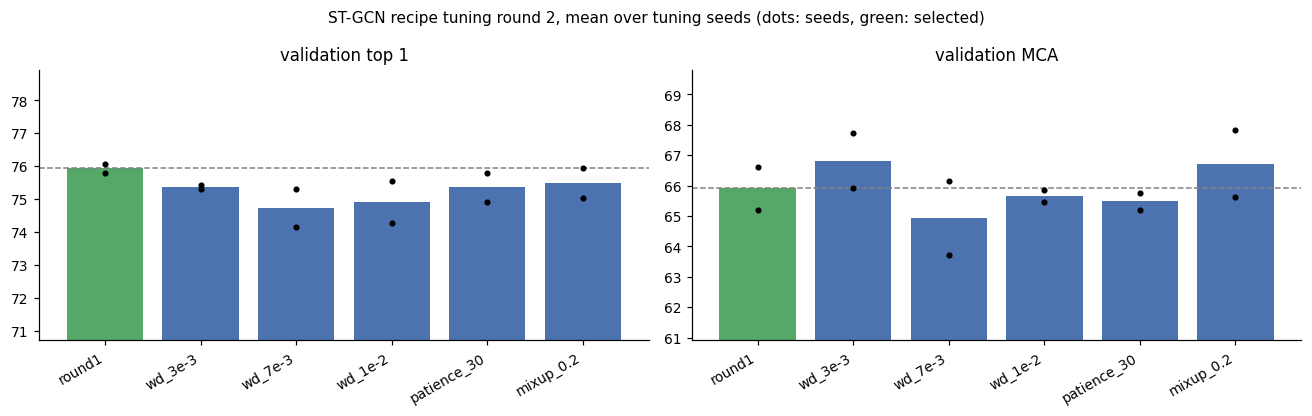

In [10]:
order = [n for n in ["round1", *FACTORS, combo_name] if n in table.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
x = np.arange(len(order))
for ax, metric, title in zip(axes, ["val_top1", "val_mca"], ["validation top 1", "validation MCA"]):
    means = [results.loc[results["config"] == n, metric].mean() for n in order]
    colours = ["#55a868" if n == selected else "#b0b0b0" if n == "round1" else "#4c72b0" for n in order]
    ax.bar(x, 100 * np.array(means), color=colours)
    for i, n in enumerate(order):
        ax.scatter(np.full(len(SEEDS), i), 100 * results.loc[results["config"] == n, metric], color="black", s=9, zorder=3)
    ax.axhline(100 * results.loc[results["config"] == "round1", metric].mean(), color="grey", ls="--", lw=1)
    ax.set_xticks(x, order, rotation=30, ha="right")
    ax.set_ylim(100 * min(means) - 4, 100 * max(means) + 3)
    ax.set_title(title)
fig.suptitle("ST-GCN recipe tuning round 2, mean over tuning seeds (dots: seeds, green: selected)", fontsize=10)
fig.tight_layout()
slog.report_matplotlib_figure("recipe v2 comparison", "val", figure=fig, iteration=0, report_interactive=False)
plt.show()

In [11]:
recipe = {"model": "ST-GCN", "normalisation": "body_court", "selected": selected,
          "changes_from_round1": ({} if selected == "round1" else (combo if selected == combo_name else FACTORS[selected])),
          **{k: v for k, v in FIXED.items() if k != "num_epochs"}, **selected_cfg,
          "num_epochs": FIXED["num_epochs"],
          "tuning": {"seeds": SEEDS, "val_top1": round(float(table.loc[selected, "val top1"]), 4),
                     "round1_val_top1": round(float(base["val top1"]), 4)}}
with open(f"{REPO}/configs/stgcn_recipe_v2.json", "w") as f:
    json.dump(recipe, f, indent=2)
task.upload_artifact("selected_recipe", artifact_object=f"{REPO}/configs/stgcn_recipe_v2.json")
task.upload_artifact("results", artifact_object=results_path)
task.close()
recipe

{'model': 'ST-GCN',
 'normalisation': 'body_court',
 'selected': 'round1',
 'changes_from_round1': {},
 'augmentation': 'advanced',
 'min_native_frames': 5,
 'batch_size': 16,
 'lr': 0.01,
 'momentum': 0.9,
 'gamma': 0.1,
 'select_metric': 'top1',
 'weight_decay': 0.005,
 'label_smoothing': 0.0,
 'schedule': 'step10',
 'target_per_class': 300,
 'patience': 20,
 'mixup_alpha': 0.0,
 'num_epochs': 70,
 'tuning': {'seeds': [11, 22], 'val_top1': 0.7593, 'round1_val_top1': 0.7593}}

## Notes for the thesis

- Round 2 starts from the round 1 recipe, not the original baseline, so gains compound rather than repeat.
- Mixup uses soft cross entropy on blended labels; evaluation (train/val/test) is never mixed, only training
  batches.
- If nothing in round 2 clears the selection rule, `configs/stgcn_recipe_v2.json` records `selected: "round1"`
  and the round 1 recipe carries forward unchanged, which is itself a reportable negative result: the top 1
  gap to Li et al. would then be attributed to data or architecture differences rather than training recipe.
- The final ST-GCN reporting notebook should point at whichever config file (`stgcn_recipe.json` or
  `stgcn_recipe_v2.json`) was actually used, so the thesis methods section can cite the right one.